In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import torch
from datasets import load_dataset
from torchvision.transforms import v2
import dotenv
import os

In [16]:
dotenv.load_dotenv()
#print(os.getenv("HF_TOKEN")) #HF_TOKEN prescence in envvars is automatically detected by huggingface functions

True

In [17]:
import os
import ssl
import torch
from torch.utils.data import Dataset, random_split
from torchvision.datasets import MNIST as TorchMNIST
from torchvision.transforms import v2

# 1. Programmatically bypass your local SSL certificate verification error
ssl._create_default_https_context = ssl._create_unverified_context

# 2. Updated Transforms for MNIST
# We add Grayscale(3) and Resize(32) so this dataset acts exactly like CIFAR-10
train_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),  # Converts 1-channel MNIST to 3-channel pseudo-RGB
    v2.Resize((32, 32)),                  # Upscales from 28x28 to your original 32x32 size
    v2.RandomCrop(32, padding=4), 
    v2.RandomHorizontalFlip(p=0.5), 
    v2.ToDtype(torch.float32, scale=True),
    # Adjusted mean/std vectors to match 3 channels instead of 1
    v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081]) 
])

eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(num_output_channels=3),
    v2.Resize((32, 32)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307, 0.1307, 0.1307], std=[0.3081, 0.3081, 0.3081])
])

# 3. Download and load via Torchvision (Fast ~11MB download total)
full_train_raw = TorchMNIST(root='./data', train=True, download=True)
full_test_raw = TorchMNIST(root='./data', train=False, download=True)

# 4. Slice the raw data to match your percentages (5% train, 2% test)
train_size = int(0.05 * len(full_train_raw))   # 5% of 60,000 = 3,000
test_size = int(0.02 * len(full_test_raw))     # 2% of 10,000 = 200

train_subset, _ = random_split(full_train_raw, [train_size, len(full_train_raw) - train_size])
test_subset, _ = random_split(full_test_raw, [test_size, len(full_test_raw) - test_size])

class MNISTWrapper(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # PyTorch MNIST returns a tuple of (PIL.Image, int_label)
        img, label = self.subset[idx] 
        img = self.transform(img)
        return img, label

dataset_train = MNISTWrapper(train_subset, train_transform)
print(f"Training dataset size: {len(dataset_train)}") # Outputs 3000

val_size = len(test_subset) // 2
test_slice_1, test_slice_2 = random_split(test_subset, [val_size, len(test_subset) - val_size])

dataset_val = MNISTWrapper(test_slice_1, eval_transform)
dataset_test = MNISTWrapper(test_slice_2, eval_transform)

print(f"Validation dataset size: {len(dataset_val)}") # Outputs 100
print(f"Testing dataset size: {len(dataset_test)}")   # Outputs 100


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.20MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 211kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 743kB/s] 
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.85MB/s]

Training dataset size: 3000
Validation dataset size: 100
Testing dataset size: 100


In [18]:
train_loader = torch.utils.data.DataLoader(dataset_train, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset_test, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset_val, batch_size=64, shuffle=True)

In [19]:
import architectures.BasicNet

In [20]:
BasicNet = architectures.BasicNet.BasicNet()

In [80]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def train(model, dataloader_train,dataload_val):
    model.train()
    count = 0
    optimizer = torch.optim.SGD(model.parameters(), lr=1e-3) #minibatch
    for batch_index, (image, label) in enumerate(dataloader_train):
        optimizer.zero_grad() #zero out the gradients
        print(image.shape)

        output = model(image.reshape(image.size(0), -1)) #keep the number of rows as the number of samples (batch size) and the rest are the features
        loss = torch.nn.functional.cross_entropy(output, label) 
        loss.backward()# computer gradients
        optimizer.step()

def test(model, dataset_test):
    for batch_index, (image,label) in enumerate(dataset_test):
        with torch.no_grad():
            output=model(image.reshape(image.size(0),-1))

            img_numpy = image[0].cpu().detach()
            print(img_numpy.shape)
            if img_numpy.ndim == 3:
                img_numpy = img_numpy.permute(2,1,0)

            plt.imshow(img_numpy)
            plt.axis('off')  # Hide the pixel grid axes
            plt.show()
            print(torch.argmax(output[0]))


class BasicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers=nn.Sequential(nn.Linear(3072,10),nn.Sigmoid()) ##since there are 10 classes the logits must be 10
        #self.layers=nn.Sequential(nn.Conv2d(in_channels=3, out_channels=96, kernel_size=(11,11), stride=4),
        #   nn.ReLU(), 
        #    nn.MaxPool2d((3,3), stride=2),
        #    nn.Linear(4096,1000),
        #    nn.Linear(1000,10))
        
    def forward(self,x):
        return self.layers(x) 
    


In [81]:
bn = BasicNet()
train(bn,train_loader, val_loader)

torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 32, 32])
torch.Size([64, 3, 3

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


torch.Size([3, 32, 32])


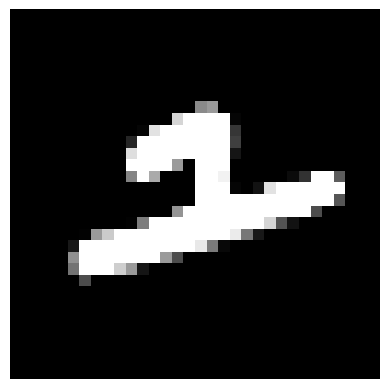

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.42421296..2.8087587].


tensor(8)
torch.Size([3, 32, 32])


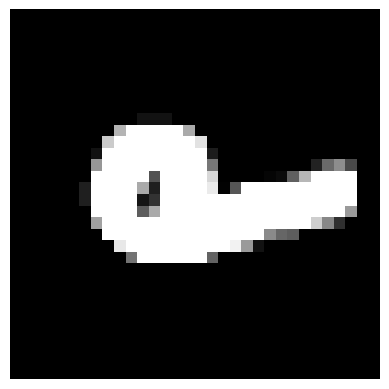

tensor(8)


In [82]:
test(bn,test_loader)